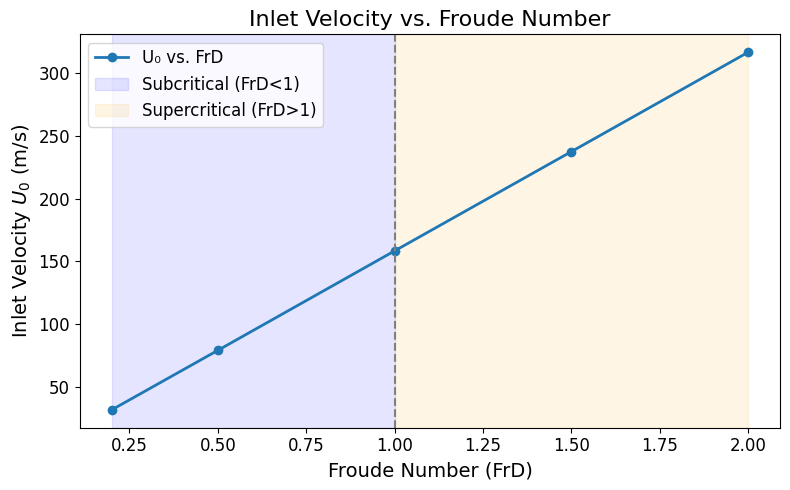

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data: Froude numbers and corresponding inlet velocities
FrD = np.array([0.2, 0.5, 1.0, 1.5, 2.0])
U0  = np.array([31.69106957, 79.12980152, 158.4553478, 237.653611, 316.9106957])

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot inlet velocity vs. Froude number
ax.plot(FrD, U0, marker='o', linewidth=2, markersize=6, label='U₀ vs. FrD')

# Shade subcritical region (FrD < 1)
ax.axvspan(FrD.min(), 1.0, color='blue', alpha=0.1, label='Subcritical (FrD<1)')

# Shade supercritical region (FrD > 1)
ax.axvspan(1.0, FrD.max(), color='orange', alpha=0.1, label='Supercritical (FrD>1)')

# Mark the critical Froude number FrD = 1
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.5)

# Set labels and title
ax.set_xlabel('Froude Number (FrD)', fontsize=14)
ax.set_ylabel('Inlet Velocity $U_0$ (m/s)', fontsize=14)
ax.set_title('Inlet Velocity vs. Froude Number', fontsize=16)

# Improve tick formatting
ax.tick_params(axis='both', which='major', labelsize=12)

# Add a legend
ax.legend(fontsize=12)

# Tight layout for publication
fig.tight_layout()

# Save to file
#fig.savefig('inlet_velocity_vs_froude.png', dpi=300)

# Show the plot
plt.show()


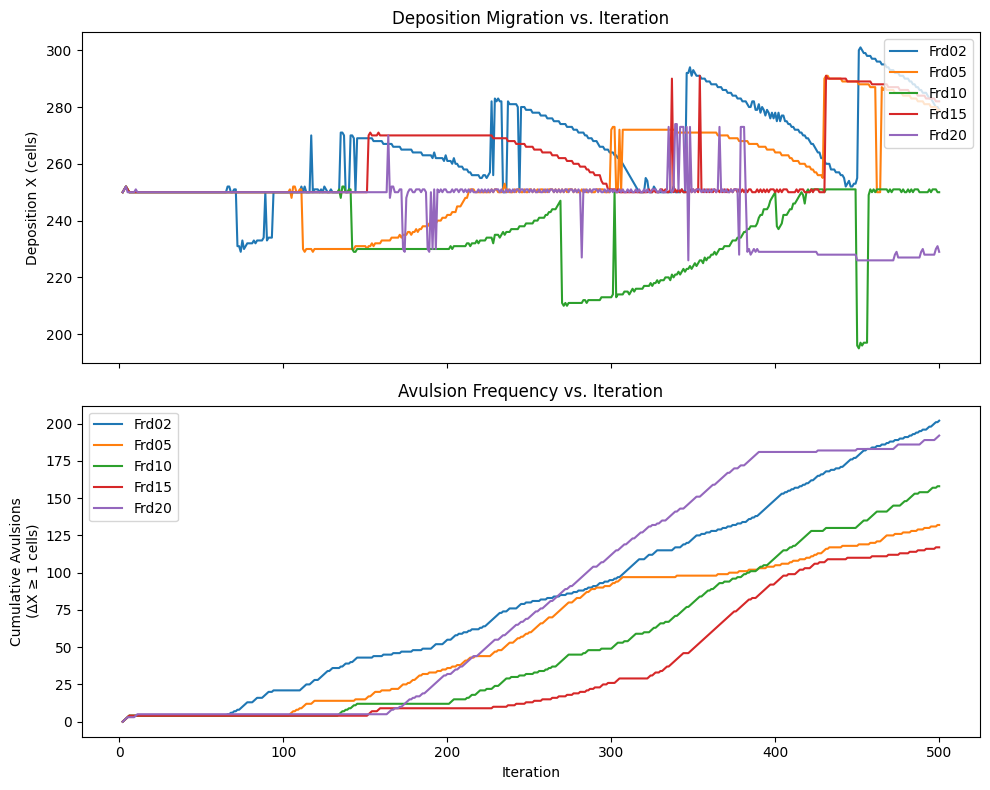

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── PARAMETERS ────────────────────────────────────────────────────────────────
FILENAME    = 'xdistance.csv'   # your 5-column table
THRESHOLD   = 1                 # minimum x-shift (cells) to count as an avulsion

# ─── 1) Load your deposition-X-distance data ──────────────────────────────────
df = pd.read_csv(FILENAME)

# ─── 2) Compute “significant” avulsions ───────────────────────────────────────
delta       = df.diff().abs()               # absolute change per iteration
avulsions   = (delta >= THRESHOLD).astype(int)
cum_avulse  = avulsions.cumsum()            # cumulative count

# ─── 3) Plot the results ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# (a) Deposition migration
for col in df.columns:
    axes[0].plot(df.index + 2, df[col], label=col, linewidth=1.5)
axes[0].set_ylabel('Deposition X (cells)')
axes[0].set_title('Deposition Migration vs. Iteration')
axes[0].legend(fontsize=10, loc='upper right')

# (b) Cumulative significant avulsions
for col in df.columns:
    axes[1].plot(df.index + 2, cum_avulse[col], linewidth=1.5)
axes[1].set_ylabel('Cumulative Avulsions\n(ΔX ≥ %d cells)' % THRESHOLD)
axes[1].set_xlabel('Iteration')
axes[1].set_title('Avulsion Frequency vs. Iteration')
axes[1].legend(df.columns, fontsize=10, loc='upper left')

plt.tight_layout()
#plt.savefig('xdistance_avulsion_analysis_thresholded.png', dpi=300)
plt.show()


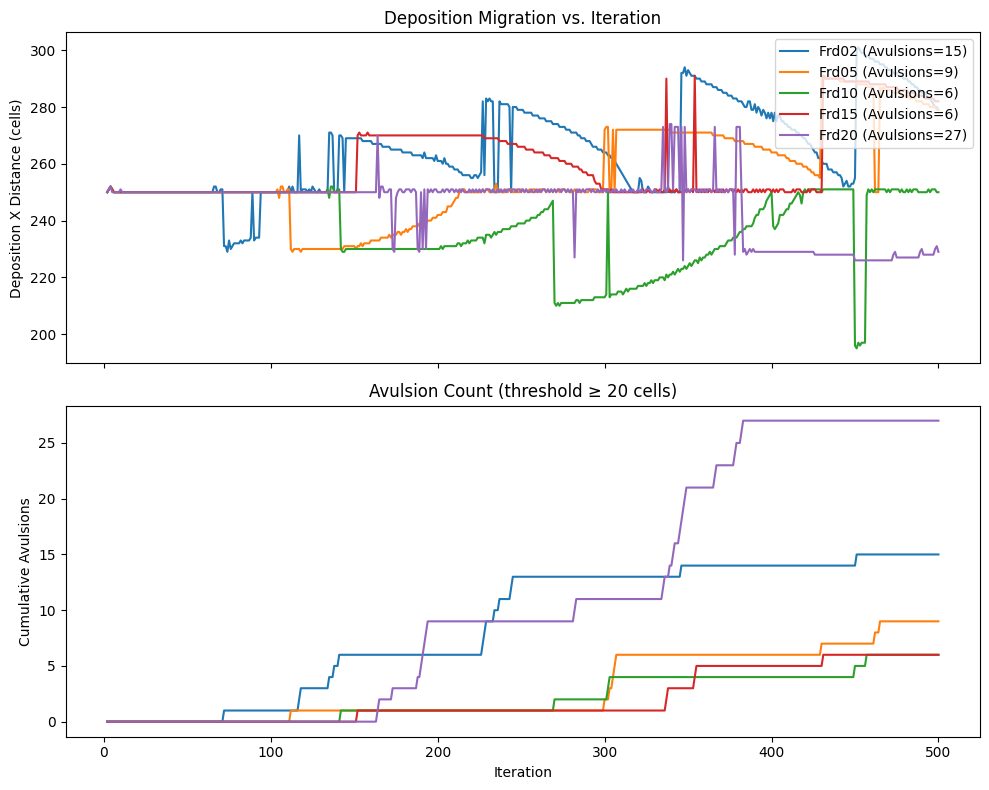

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1) Load the deposition-X-distance data ─────────────────────────────────────
# Ensure you have 'xdistance.csv' with header: Frd02,Frd05,Frd10,Frd15,Frd20
df = pd.read_csv('xdistance.csv')

# ─── 2) Define avulsion threshold ───────────────────────────────────────────────
avulsion_threshold = 20  # minimum cell-change to count as avulsion

# ─── 3) Compute “avulsion” events with threshold ────────────────────────────────
delta         = df.diff().abs()                               # absolute change per iteration
avulsions     = (delta >= avulsion_threshold).astype(int)     # 1 if change ≥ threshold
cum_avulsions = avulsions.cumsum()                            # cumulative avulsion count
total_avulse  = cum_avulsions.iloc[-1]                        # total per FrD

# ─── 4) Plot results and annotate totals ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# (a) Deposition X-distance vs. iteration, legend shows total avulsions
for col in df.columns:
    axes[0].plot(df.index + 2, df[col],
                 label=f'{col} (Avulsions={total_avulse[col]})',
                 linewidth=1.5)
axes[0].set_ylabel('Deposition X Distance (cells)')
axes[0].set_title('Deposition Migration vs. Iteration')
axes[0].legend(fontsize=10, loc='upper right')

# (b) Cumulative avulsions vs. iteration
for col in df.columns:
    axes[1].plot(df.index + 2, cum_avulsions[col], linewidth=1.5)
axes[1].set_ylabel('Cumulative Avulsions')
axes[1].set_xlabel('Iteration')
axes[1].set_title(f'Avulsion Count (threshold ≥ {avulsion_threshold} cells)')

plt.tight_layout()
#plt.savefig('xdistance_avulsion_thresholded.png', dpi=300)
plt.show()


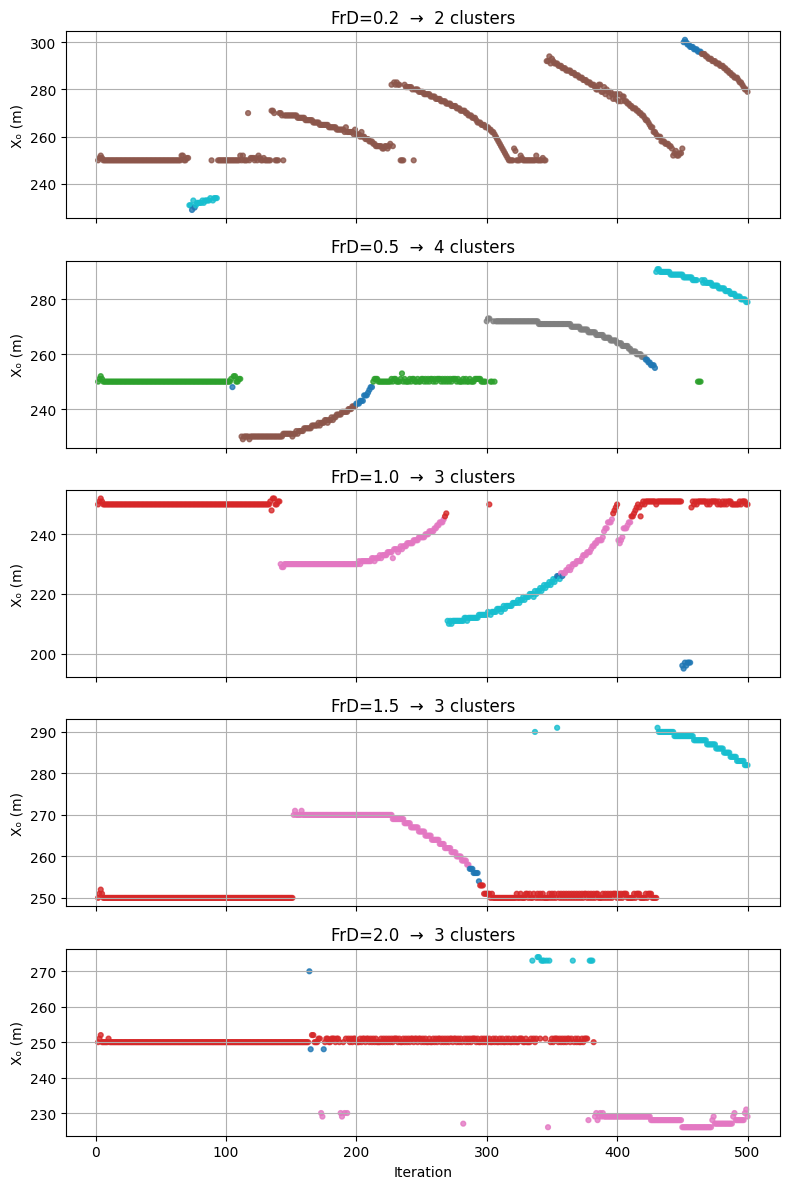

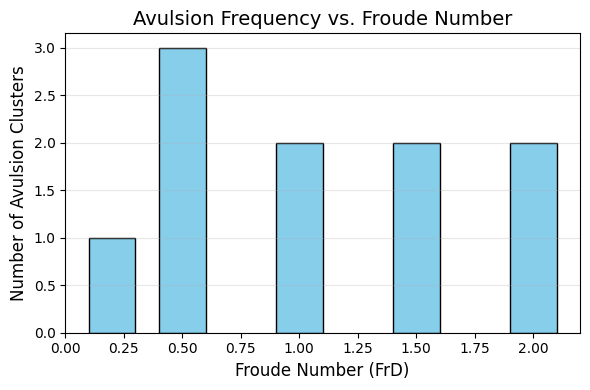

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# ─── 1) Load data from CSV ─────────────────────────────────────────────────────
# CSV should have columns: 'Frd02','Frd05','Frd10','Frd15','Frd20'
df = pd.read_csv('xdistance.csv')

# Drop any header rows if necessary, extract only rows 2–500
# (assuming the CSV aligns so that df.iloc[0] is iteration 2, etc.)
runs = {
    0.2: df['Frd02'].values,
    0.5: df['Frd05'].values,
    1.0: df['Frd10'].values,
    1.5: df['Frd15'].values,
    2.0: df['Frd20'].values,
}

# ─── 2) Cluster & Multi-panel Scatter ──────────────────────────────────────────
fig, axes = plt.subplots(len(runs), 1, figsize=(8, 12), sharex=True)

for ax, (frd, xpos) in zip(axes, runs.items()):
    # 1D clustering of X positions (eps in grid-cells, min_samples = 5 iterations)
    clustering = DBSCAN(eps=1, min_samples=10).fit(xpos.reshape(-1,1))
    labels = clustering.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    iterations = np.arange(2, 2 + len(xpos))  # map array index → iteration number
    sc = ax.scatter(iterations, xpos, c=labels, cmap='tab10', s=12, alpha=0.8)
    ax.set_title(f'FrD={frd:.1f}  →  {n_clusters} clusters')
    ax.set_ylabel('Xₒ (m)')
    ax.grid(True)

axes[-1].set_xlabel('Iteration')
plt.tight_layout()
plt.show()

# ─── 3) Avulsion Frequency vs. Froude Number ──────────────────────────────────
frds = []
avulsions = []
for frd, xpos in runs.items():
    labels = DBSCAN(eps=1, min_samples=10).fit_predict(xpos.reshape(-1,1))
    unique, counts = np.unique(labels[labels>=0], return_counts=True)
    # one main lobe = largest cluster; others = avulsions
    avul_count = len(unique) - 1
    frds.append(frd)
    avulsions.append(avul_count)

plt.figure(figsize=(6,4))
plt.bar(frds, avulsions, width=0.2, color='skyblue', edgecolor='k')
plt.xlabel('Froude Number (FrD)', fontsize=12)
plt.ylabel('Number of Avulsion Clusters', fontsize=12)
plt.title('Avulsion Frequency vs. Froude Number', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


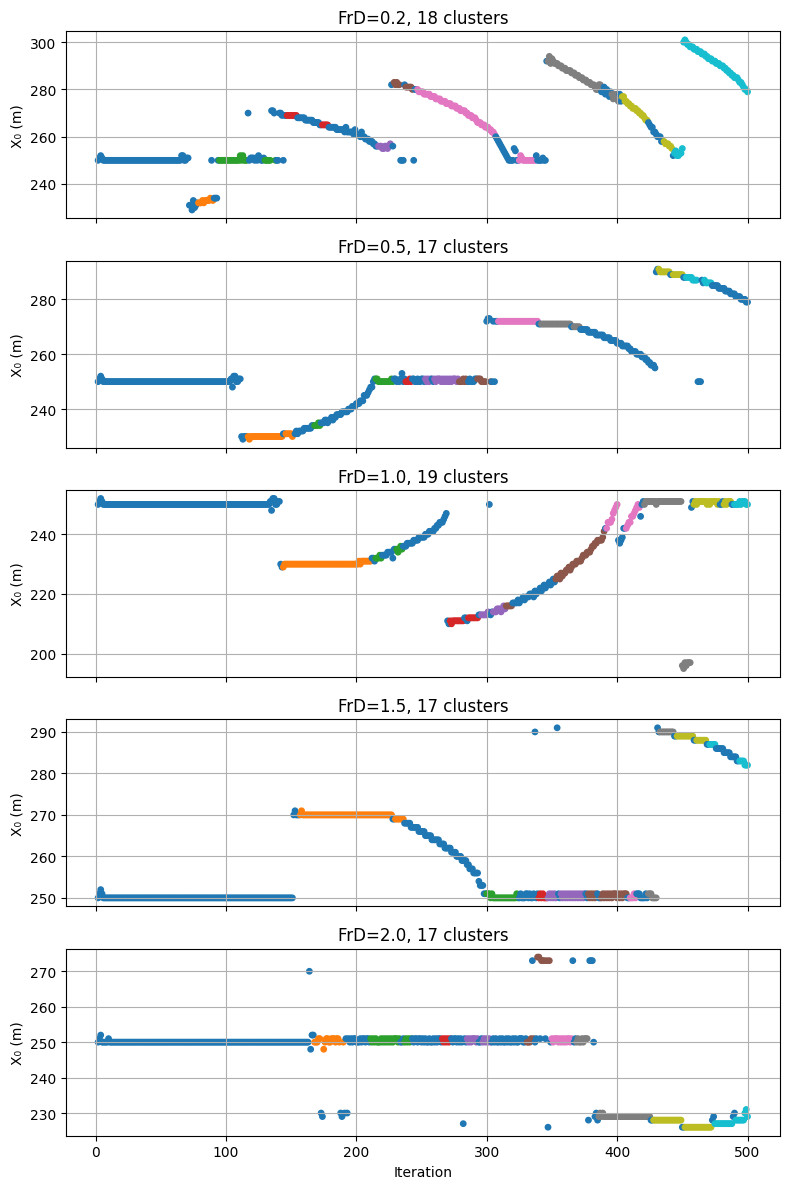

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import OPTICS

df = pd.read_csv('xdistance.csv')
runs = {
    0.2: df['Frd02'].values,
    0.5: df['Frd05'].values,
    1.0: df['Frd10'].values,
    1.5: df['Frd15'].values,
    2.0: df['Frd20'].values,
}

fig, axes = plt.subplots(len(runs),1, figsize=(8,12), sharex=True)

for ax,(frd,xpos) in zip(axes, runs.items()):
    its = np.arange(2,2+len(xpos))
    # 2-D OPTICS (time + X)
    pts = np.column_stack([its, xpos])
    cl = OPTICS(min_samples=5, max_eps=5).fit(pts)
    labels = cl.labels_
    ncl = len(set(labels)) - (1 if -1 in labels else 0)

    ax.scatter(its, xpos, c=labels, cmap='tab10', s=15)
    ax.set_title(f'FrD={frd:.1f}, {ncl} clusters')
    ax.set_ylabel('X₀ (m)')
    ax.grid(True)

axes[-1].set_xlabel('Iteration')
plt.tight_layout()
plt.show()


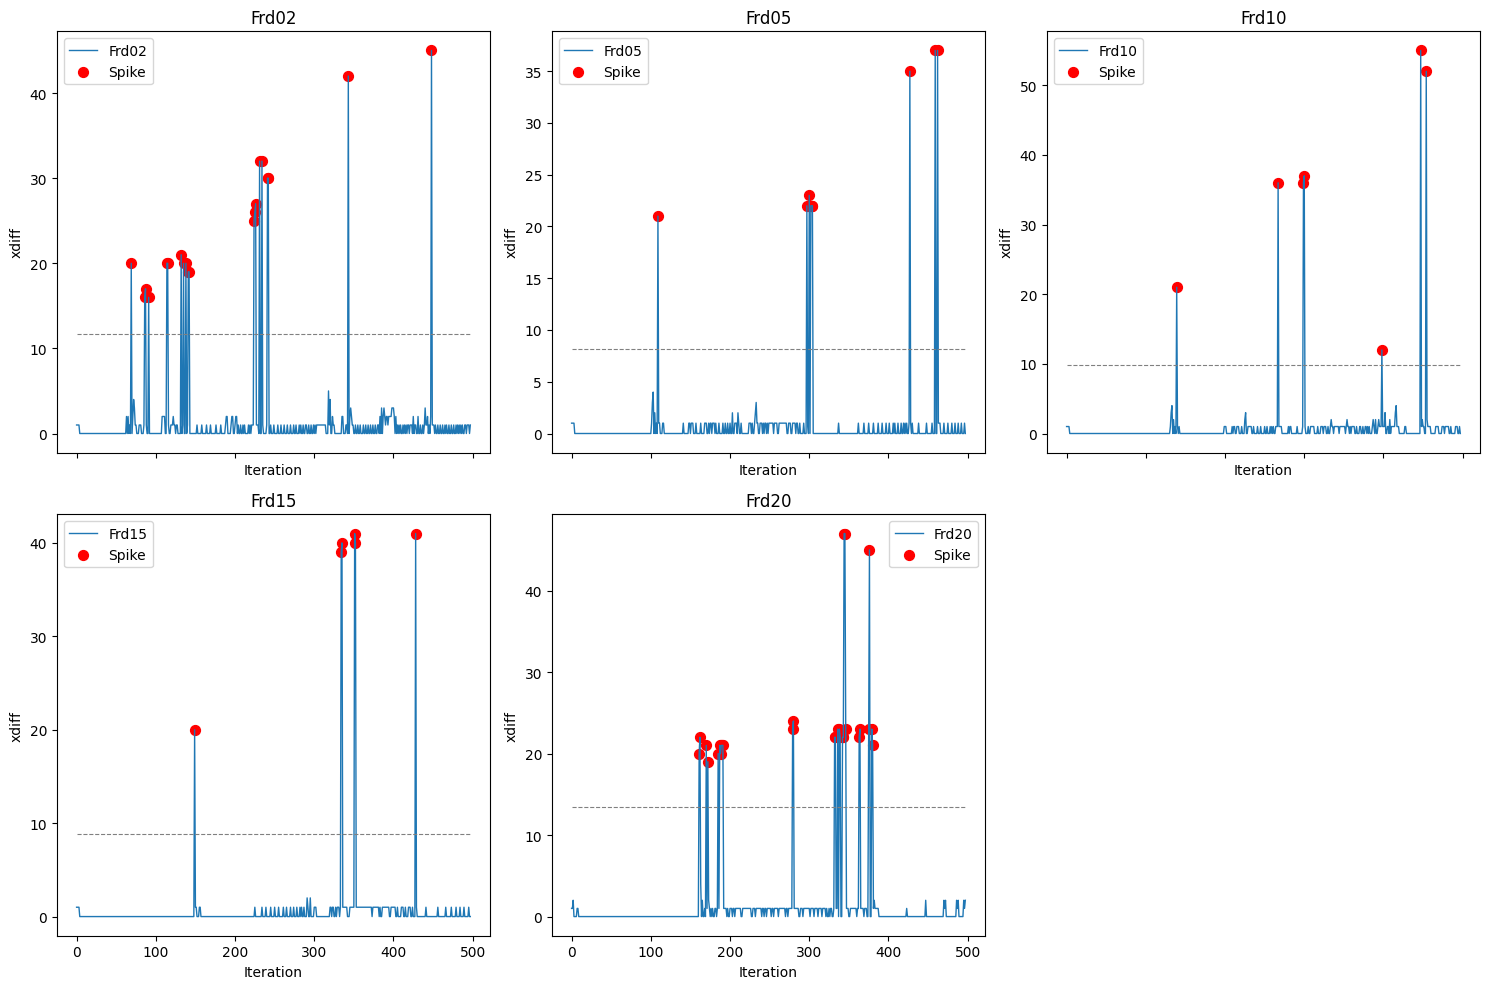

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Load the xdiff data
df = pd.read_csv('xdiff.csv')

# Calculate spike thresholds (mean + 2*std) for each Froude scenario
thresholds = df.mean() + 2 * df.std()

# Prepare subplots: one per scenario
cols = df.columns.tolist()
n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), sharex=True, sharey=False)

# Flatten axes array for easy indexing
axes = axes.flatten()

for idx, col in enumerate(cols):
    ax = axes[idx]
    ax.plot(df.index, df[col], label=col, linewidth=1)
    # Highlight spikes
    spikes = df[col] > thresholds[col]
    ax.scatter(df.index[spikes], df[col][spikes], color='red', s=50, label='Spike')
    # Draw threshold line
    ax.hlines(thresholds[col], xmin=df.index.min(), xmax=df.index.max(),
              colors='gray', linestyles='--', linewidth=0.8)
    ax.set_title(col)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('xdiff')
    ax.legend()

# Turn off any unused subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


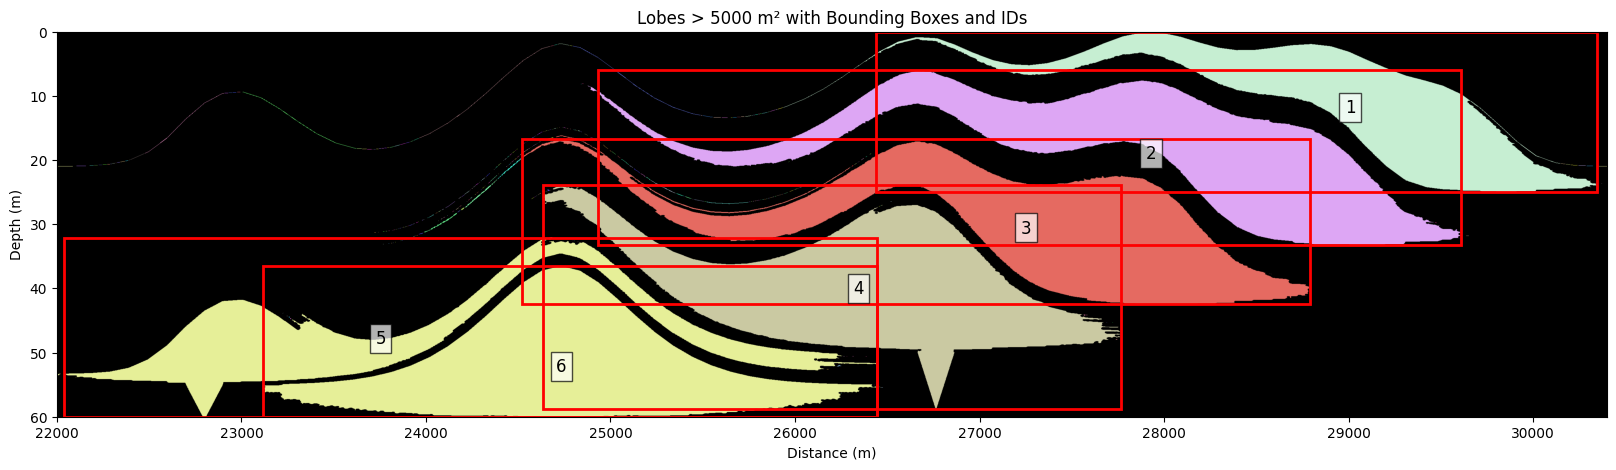

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  23398.062474  3906.748466   24.943820    29007.669831   
1        2  34986.568818  4674.846626   27.173725    27928.903622   
2        3  33316.414887  4267.484663   25.721694    27251.126171   
3        4  35273.157256  3128.834356   34.900605    26344.963193   
4        5  19621.508980  4409.815951   27.796024    23753.798669   
5        6  32152.117545  3327.607362   23.543647    24733.807564   

   Centroid Z (m)  
0       11.774270  
1       18.956079  
2       30.575557  
3       40.051527  
4       47.858802  
5       52.109498  

Compensation Index (CI): 0.518
Lobe 1 - Average Thickness: 5.99 m
Lobe 2 - Average Thickness: 7.48 m
Lobe 3 - Average Thickness: 7.81 m
Lobe 4 - Average Thickness: 11.27 m
Lobe 5 - Average Thickness: 4.45 m
Lobe 6 - Average Thickness: 9.66 m


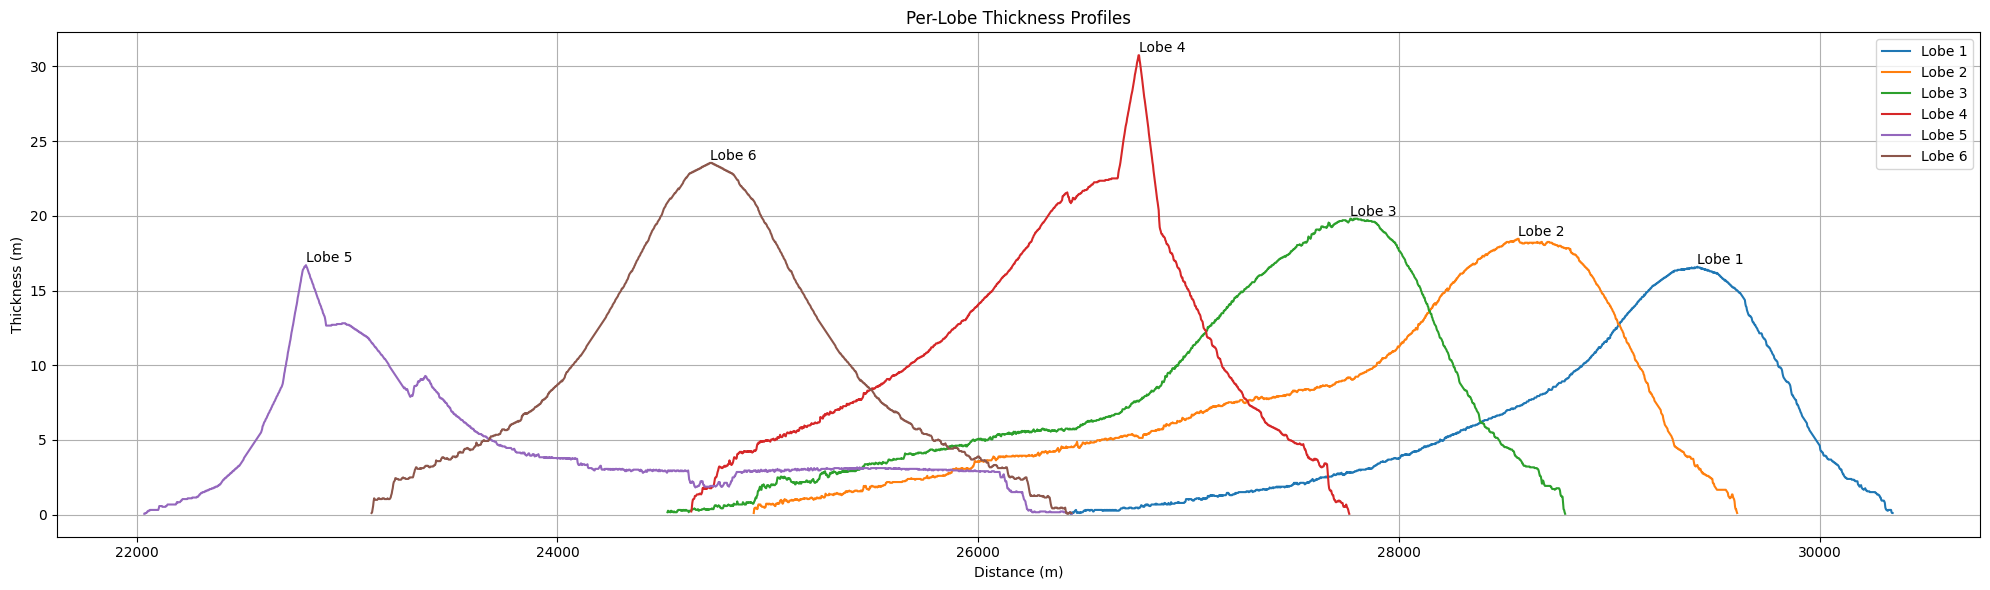

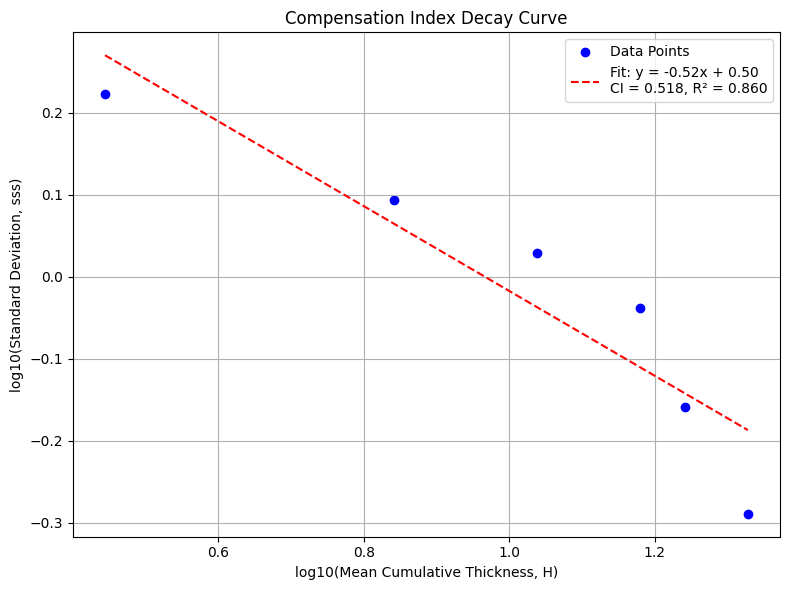


Compensation Index (CI): 0.518
R² of power-law fit: 0.860


In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 30400 - 22000  # 7000 m 29000-22000
real_height_m = 60            # vertical extent in meters
min_area_m2 = 5000            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_Frd02.png")  # Ensure this image exists
#img = cv2.imread("SFM_Frd02.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22000 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22000 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [22000, 30400, 60, 0] # [22000, 29000, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 22000 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(22000, 30400, 2000) # (22000,290000,2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot decay curve of log(sss) vs. log(H) with regression fit and R² ---
if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, intercept, r_value, p_value, std_err = linregress(log_H, log_sss)
    CI = -slope
    r_squared = r_value ** 2

    # Plotting the decay curve
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, color='blue', label='Data Points')
    plt.plot(log_H, intercept + slope * log_H, color='red', linestyle='--',
             label=f'Fit: y = {slope:.2f}x + {intercept:.2f}\nCI = {-slope:.3f}, R² = {r_squared:.3f}')
    plt.xlabel('log10(Mean Cumulative Thickness, H)')
    plt.ylabel('log10(Standard Deviation, sss)')
    plt.title('Compensation Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nCompensation Index (CI): {CI:.3f}")
    print(f"R² of power-law fit: {r_squared:.3f}")
else:
    print("Not enough data points to compute Compensation Index.")


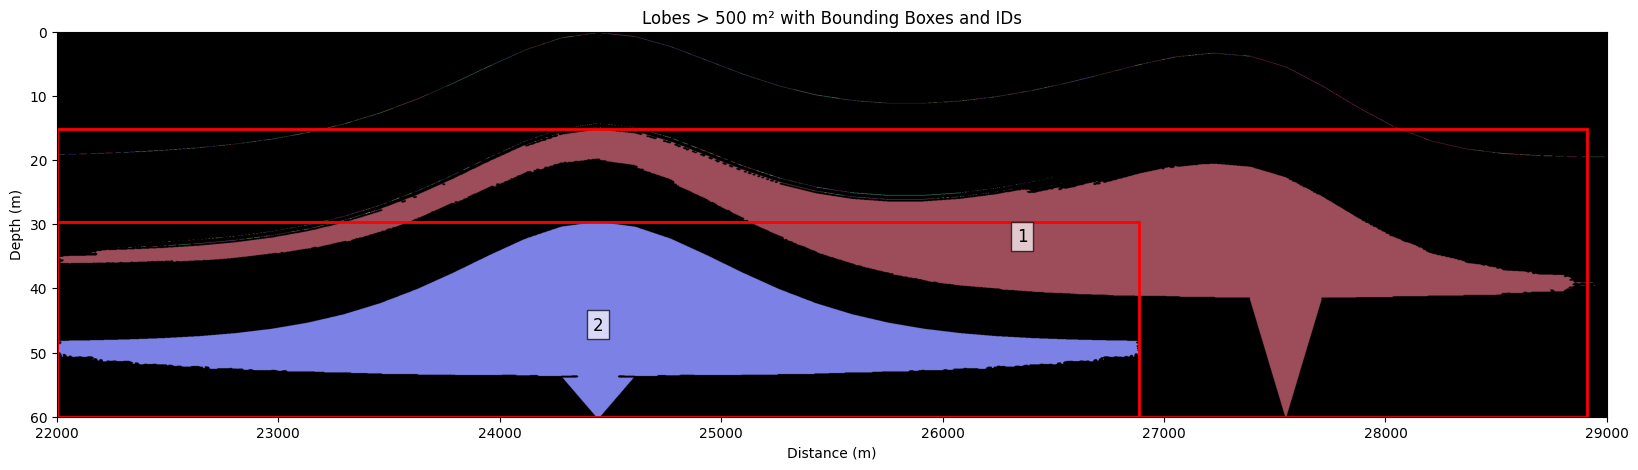

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  61420.745594  6911.217587   44.848993    26359.322307   
1        2  53551.187738  4888.951522   30.402685    24442.875574   

   Centroid Z (m)  
0       31.840788  
1       45.699868  

Compensation Index (CI): 0.730
Lobe 1 - Average Thickness: 8.89 m
Lobe 2 - Average Thickness: 10.95 m


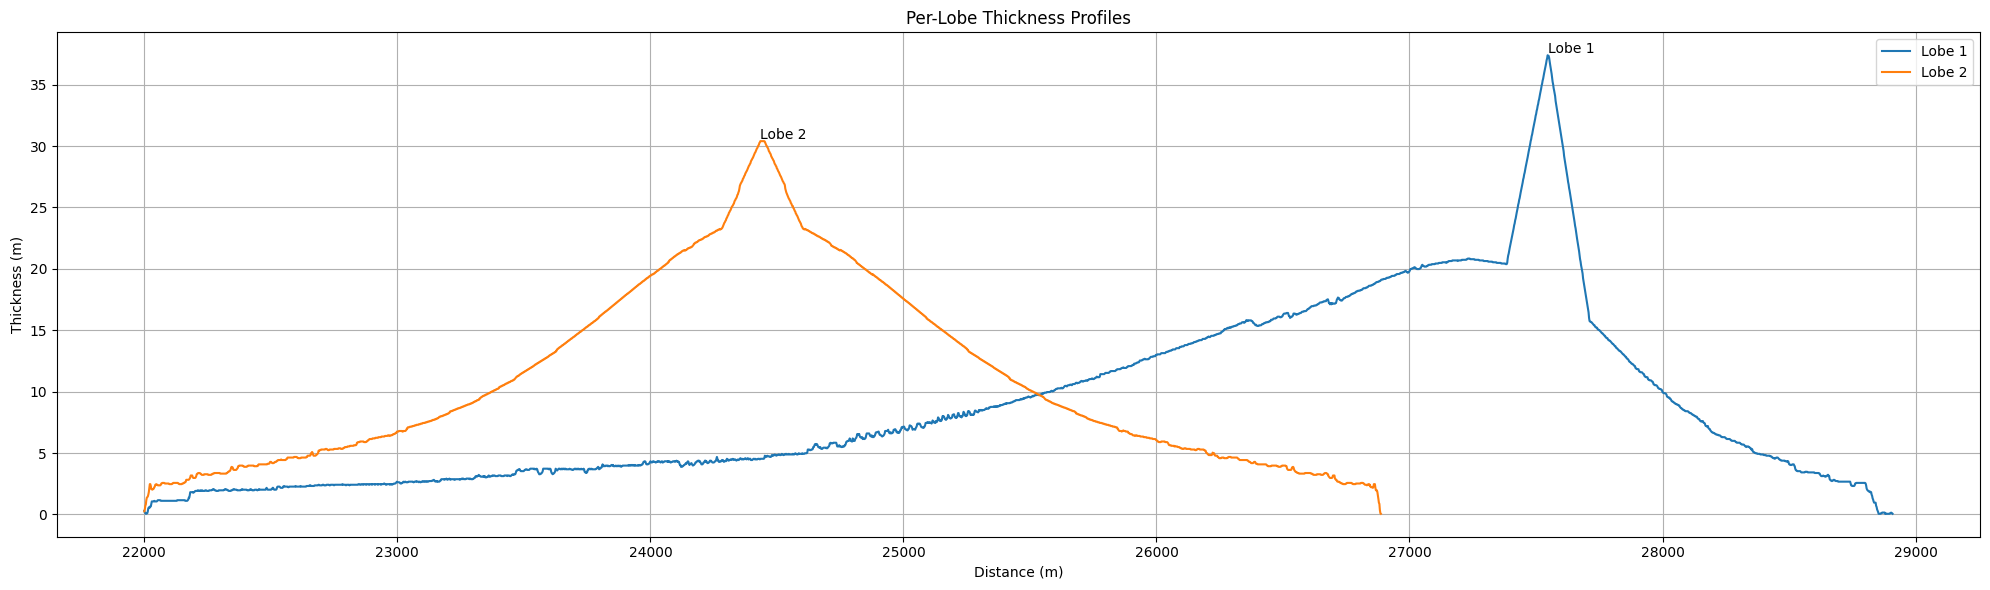

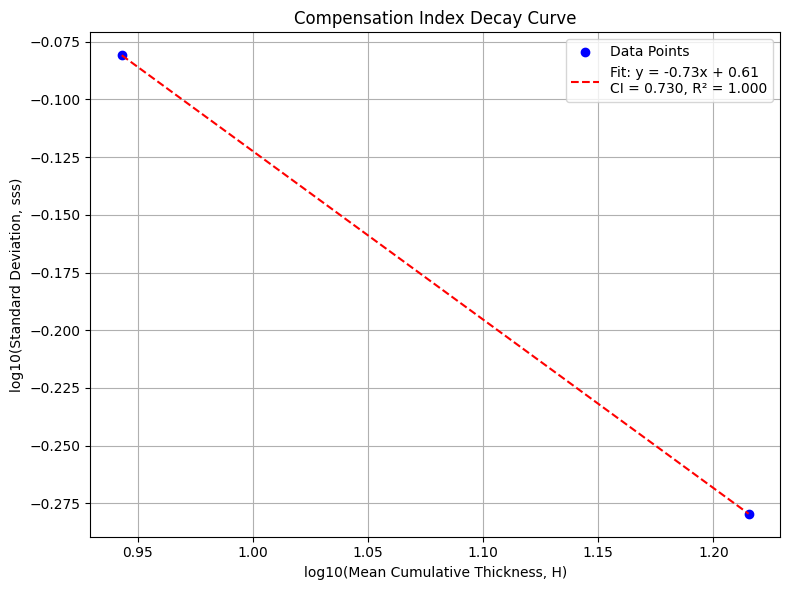


Compensation Index (CI): 0.730
R² of power-law fit: 1.000


In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 29000 - 22000  # 7000 m
real_height_m = 60            # vertical extent in meters
min_area_m2 = 500            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_Frd15.png")  # Ensure this image exists
#img = cv2.imread("SFM_Frd02.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22000 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22000 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [22000, 29000, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 22000 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(22000, 29000, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot decay curve of log(sss) vs. log(H) with regression fit and R² ---
if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, intercept, r_value, p_value, std_err = linregress(log_H, log_sss)
    CI = -slope
    r_squared = r_value ** 2

    # Plotting the decay curve
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, color='blue', label='Data Points')
    plt.plot(log_H, intercept + slope * log_H, color='red', linestyle='--',
             label=f'Fit: y = {slope:.2f}x + {intercept:.2f}\nCI = {-slope:.3f}, R² = {r_squared:.3f}')
    plt.xlabel('log10(Mean Cumulative Thickness, H)')
    plt.ylabel('log10(Standard Deviation, sss)')
    plt.title('Compensation Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nCompensation Index (CI): {CI:.3f}")
    print(f"R² of power-law fit: {r_squared:.3f}")
else:
    print("Not enough data points to compute Compensation Index.")


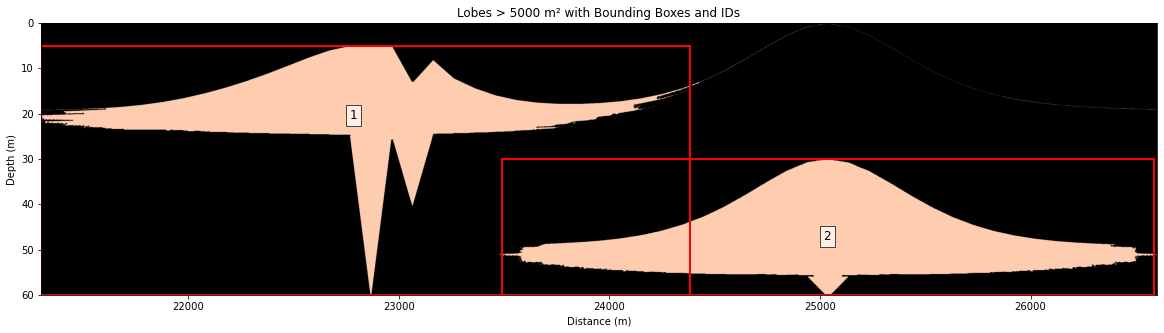

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  32001.991882  3084.387174   55.021169    22783.558780   
1        2  36318.677736  3093.916692   29.974598    25034.903298   

   Centroid Z (m)  
0       20.403685  
1       47.099600  

Compensation Index (CI): 1.080
Lobe 1 - Average Thickness: 10.38 m
Lobe 2 - Average Thickness: 11.74 m


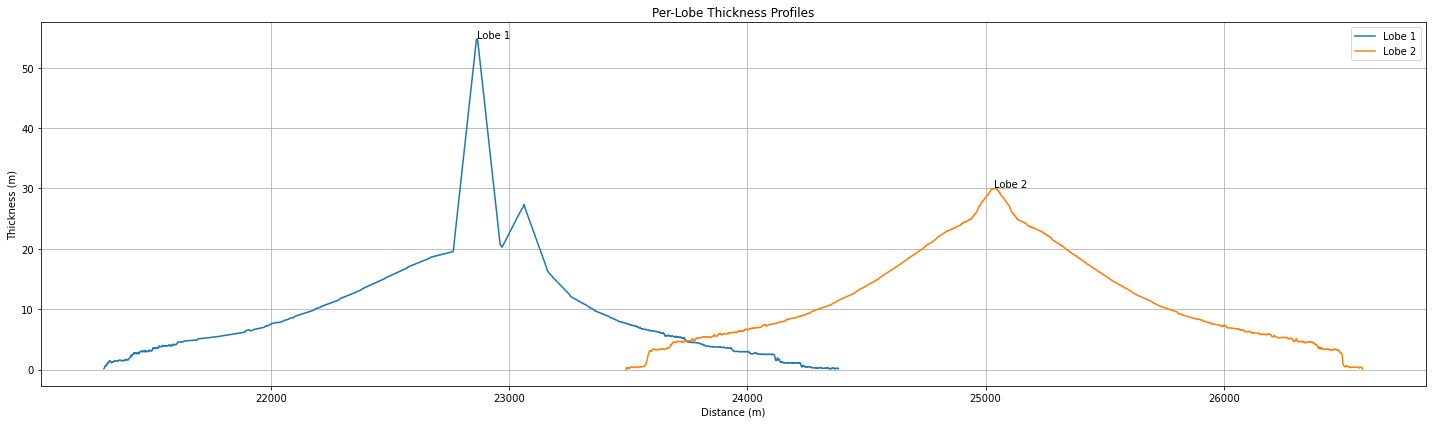

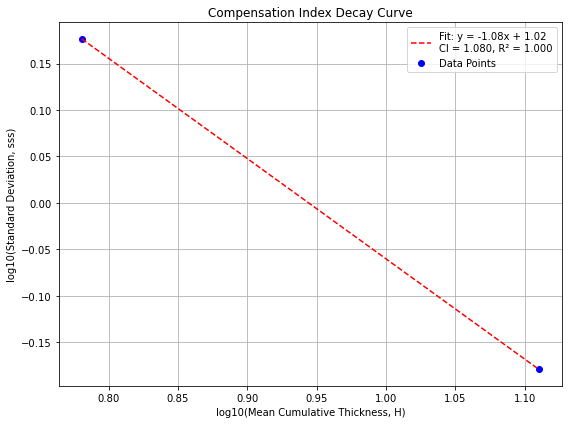


Compensation Index (CI): 1.080
R² of power-law fit: 1.000


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 26600 - 21300  # 7000 m 29000 - 22000
real_height_m = 60            # vertical extent in meters
min_area_m2 = 5000            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_Frd20c.png")  # Ensure this image exists
#img = cv2.imread("SFM_Frd02.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 21300 + cx * dx # 22000
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 21300 + c * dx #22000
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [21300, 26600, 60, 0] # [22000, 29000, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 21300 + minc * dx #22000
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(21300, 26600, 2000) # (22000, 29000, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot decay curve of log(sss) vs. log(H) with regression fit and R² ---
if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, intercept, r_value, p_value, std_err = linregress(log_H, log_sss)
    CI = -slope
    r_squared = r_value ** 2

    # Plotting the decay curve
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, color='blue', label='Data Points')
    plt.plot(log_H, intercept + slope * log_H, color='red', linestyle='--',
             label=f'Fit: y = {slope:.2f}x + {intercept:.2f}\nCI = {-slope:.3f}, R² = {r_squared:.3f}')
    plt.xlabel('log10(Mean Cumulative Thickness, H)')
    plt.ylabel('log10(Standard Deviation, sss)')
    plt.title('Compensation Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nCompensation Index (CI): {CI:.3f}")
    print(f"R² of power-law fit: {r_squared:.3f}")
else:
    print("Not enough data points to compute Compensation Index.")


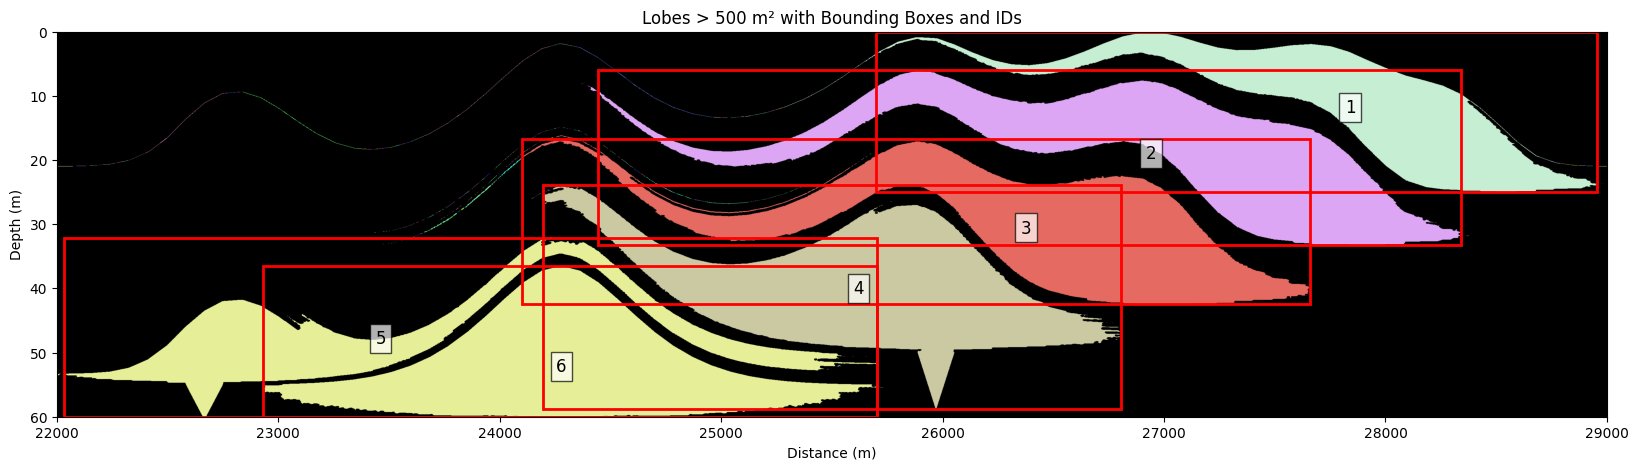

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  19498.385395  3255.623722   24.943820    27839.724859   
1        2  29155.474015  3895.705521   27.173725    26940.753019   
2        3  27763.679073  3556.237219   25.721694    26375.938476   
3        4  29394.297713  2607.361963   34.900605    25620.802661   
4        5  16351.257483  3674.846626   27.796024    23461.498891   
5        6  26793.431288  2773.006135   23.543647    24278.172970   

   Centroid Z (m)  
0       11.774270  
1       18.956079  
2       30.575557  
3       40.051527  
4       47.858802  
5       52.109498  

Compensation Index (CI): 0.518
Lobe 1 - Average Thickness: 5.99 m
Lobe 2 - Average Thickness: 7.48 m
Lobe 3 - Average Thickness: 7.81 m
Lobe 4 - Average Thickness: 11.27 m
Lobe 5 - Average Thickness: 4.45 m
Lobe 6 - Average Thickness: 9.66 m


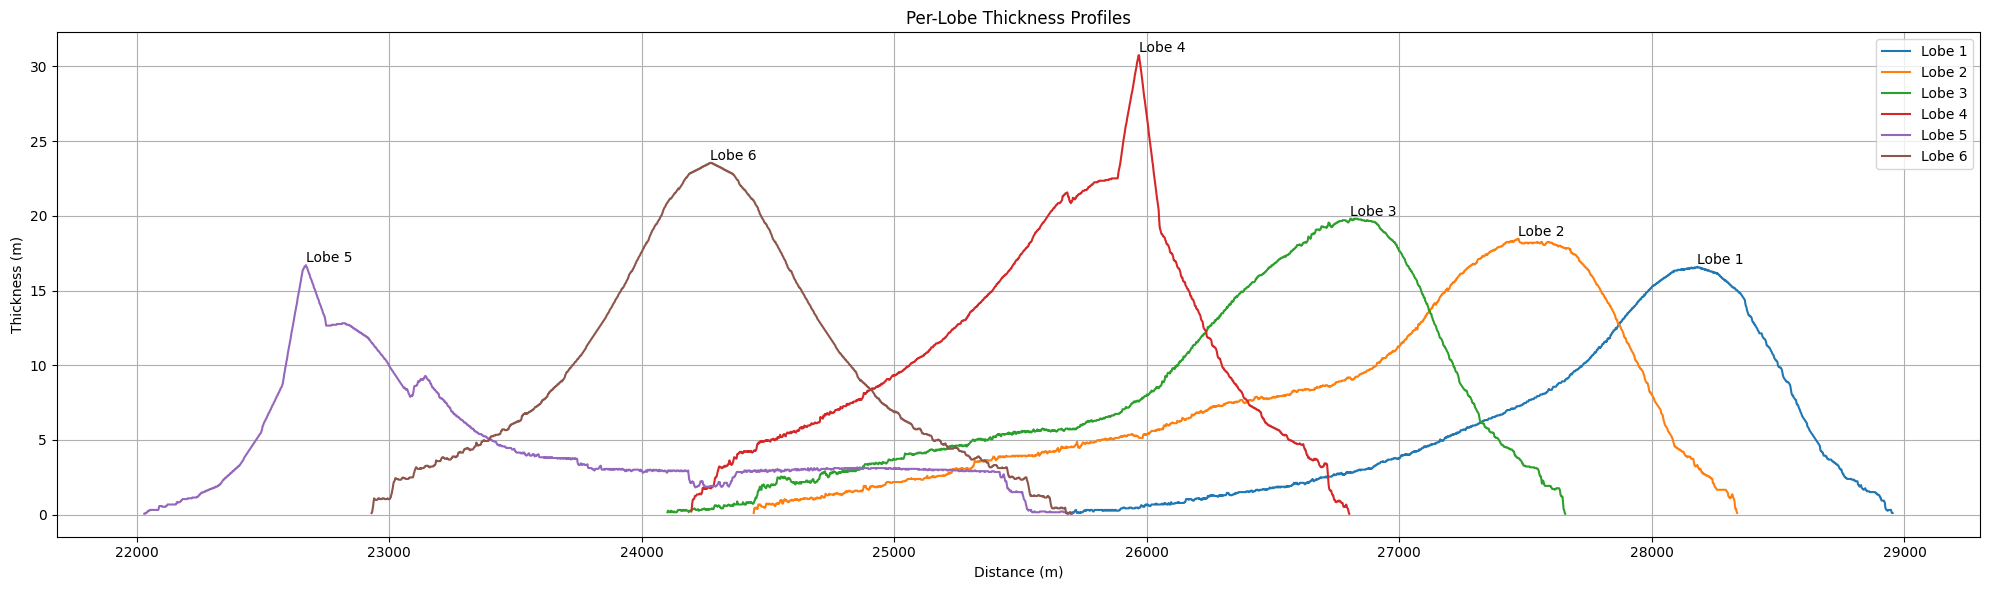

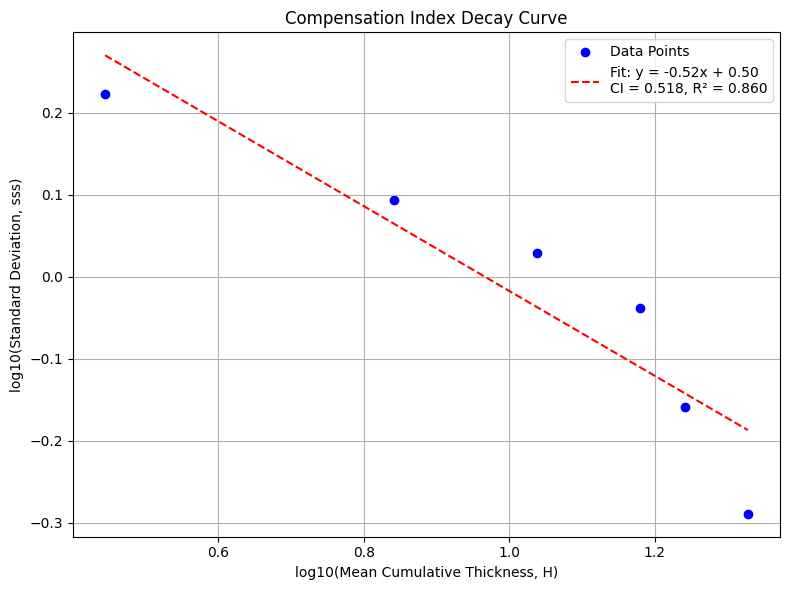


Compensation Index (CI): 0.518
R² of power-law fit: 0.860


In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 29000 - 22000  # 7000 m
real_height_m = 60            # vertical extent in meters
min_area_m2 = 500            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_Frd02.png")  # Ensure this image exists
#img = cv2.imread("SFM_Frd02.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22000 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22000 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [22000, 29000, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 22000 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(22000, 29000, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot decay curve of log(sss) vs. log(H) with regression fit and R² ---
if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, intercept, r_value, p_value, std_err = linregress(log_H, log_sss)
    CI = -slope
    r_squared = r_value ** 2

    # Plotting the decay curve
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, color='blue', label='Data Points')
    plt.plot(log_H, intercept + slope * log_H, color='red', linestyle='--',
             label=f'Fit: y = {slope:.2f}x + {intercept:.2f}\nCI = {-slope:.3f}, R² = {r_squared:.3f}')
    plt.xlabel('log10(Mean Cumulative Thickness, H)')
    plt.ylabel('log10(Standard Deviation, sss)')
    plt.title('Compensation Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nCompensation Index (CI): {CI:.3f}")
    print(f"R² of power-law fit: {r_squared:.3f}")
else:
    print("Not enough data points to compute Compensation Index.")


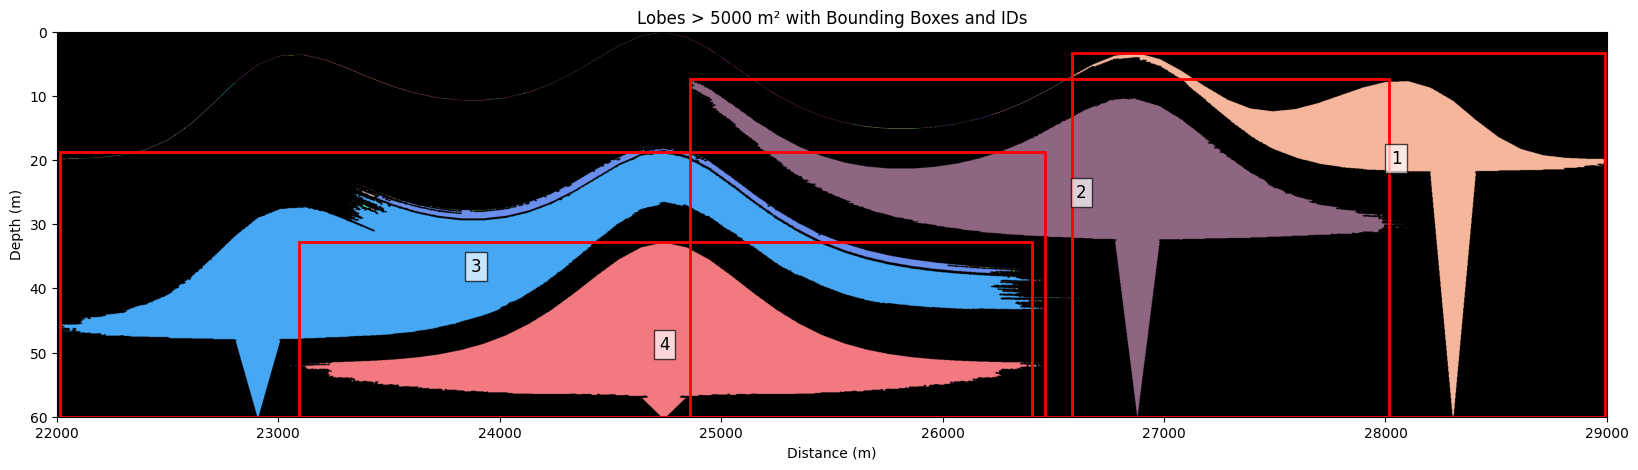

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  17628.954344  2410.552607   56.705491    28048.257850   
1        2  34522.200745  3153.605994   52.562396    26627.167354   
2        3  45871.128513  4447.393069   41.181364    23893.345522   
3        4  32688.712693  3308.773025   27.204659    24743.988187   

   Centroid Z (m)  
0       19.788109  
1       25.062996  
2       36.536171  
3       48.760241  

Compensation Index (CI): 0.846
Lobe 1 - Average Thickness: 7.31 m
Lobe 2 - Average Thickness: 10.95 m
Lobe 3 - Average Thickness: 10.31 m
Lobe 4 - Average Thickness: 9.88 m


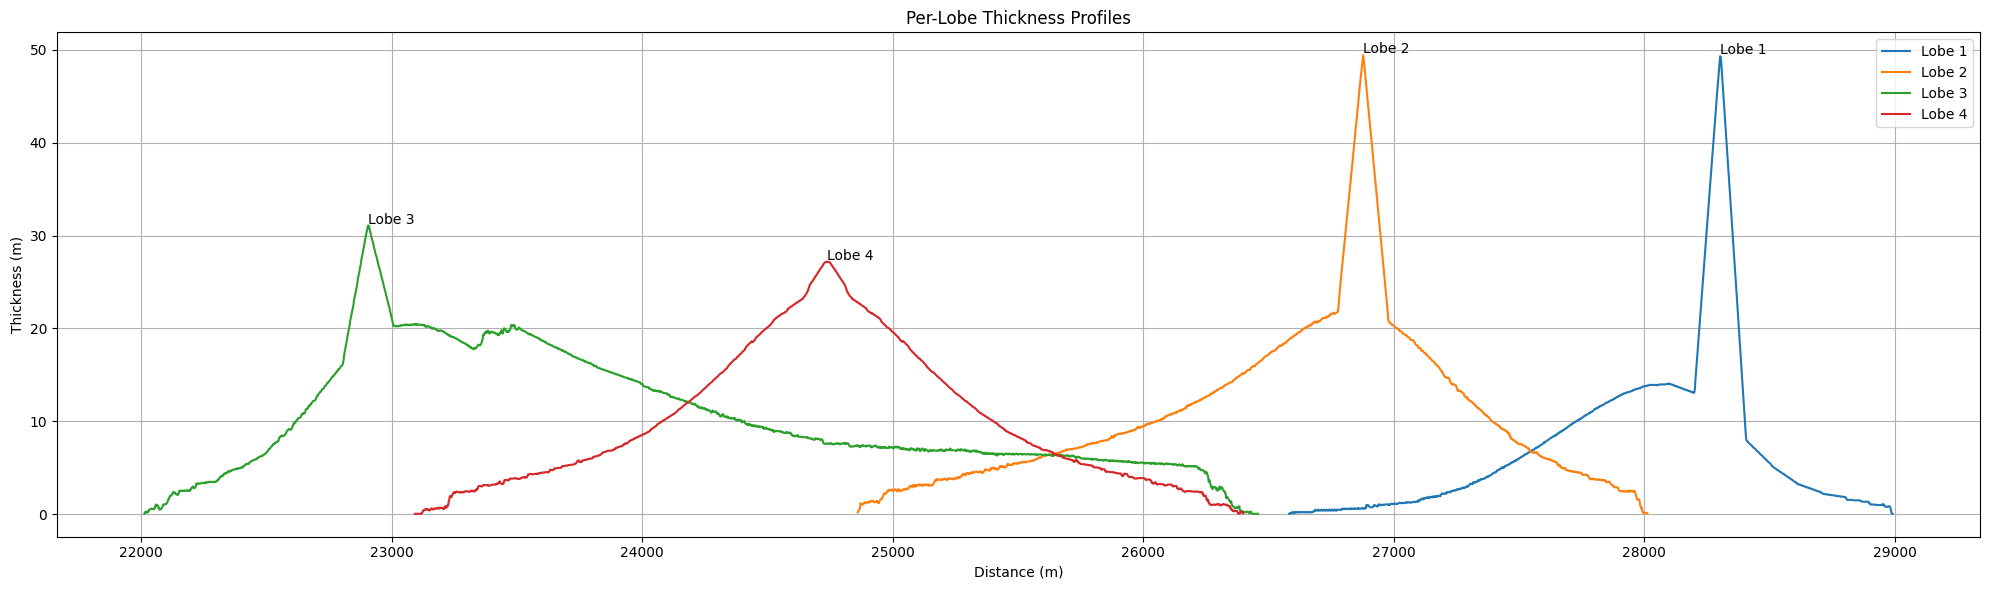

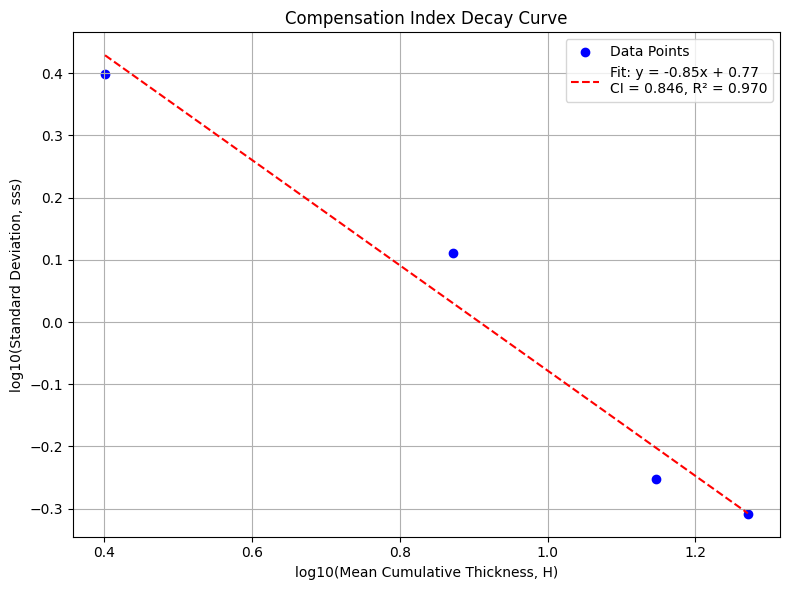


Compensation Index (CI): 0.846
R² of power-law fit: 0.970


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 29000 - 22000  # 7000 m
real_height_m = 60            # vertical extent in meters
min_area_m2 = 5000            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_Frd05b.png")  # Ensure this image exists
#img = cv2.imread("SFM_Frd02.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22000 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22000 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [22000, 29000, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 22000 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(22000, 29000, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot decay curve of log(sss) vs. log(H) with regression fit and R² ---
if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, intercept, r_value, p_value, std_err = linregress(log_H, log_sss)
    CI = -slope
    r_squared = r_value ** 2

    # Plotting the decay curve
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, color='blue', label='Data Points')
    plt.plot(log_H, intercept + slope * log_H, color='red', linestyle='--',
             label=f'Fit: y = {slope:.2f}x + {intercept:.2f}\nCI = {-slope:.3f}, R² = {r_squared:.3f}')
    plt.xlabel('log10(Mean Cumulative Thickness, H)')
    plt.ylabel('log10(Standard Deviation, sss)')
    plt.title('Compensation Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nCompensation Index (CI): {CI:.3f}")
    print(f"R² of power-law fit: {r_squared:.3f}")
else:
    print("Not enough data points to compute Compensation Index.")


In [2]:
# SCRIPT 1: Lobe Identification and Metrics Extraction
import cv2
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

# Parameters
real_width_m = 30400 - 22000
real_height_m = 60
min_area_m2 = 5000

# Load and preprocess image
img = cv2.imread("filled_lobes_Frd02.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# Label regions
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# Dimensions and scaling
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# Extract metrics and thickness profiles
metrics, thickness_profiles = [], {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22000 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Auto_Label_ID": region.label,
        "Area_m2": area_m2,
        "Width_m": width_m,
        "Height_m": height_m,
        "Centroid_X_m": cx_m,
        "Centroid_Z_m": cz_m
    })

    label_mask = (labeled == region.label)
    x_coords, thickness_vals = [], []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22000 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    thickness_profiles[region.label] = {
        "x_coords": x_coords,
        "thickness_vals": thickness_vals
    }

# Export data
pd.DataFrame(metrics).to_csv("lobe_metrics.csv", index=False)
np.save("thickness_profiles.npy", thickness_profiles)


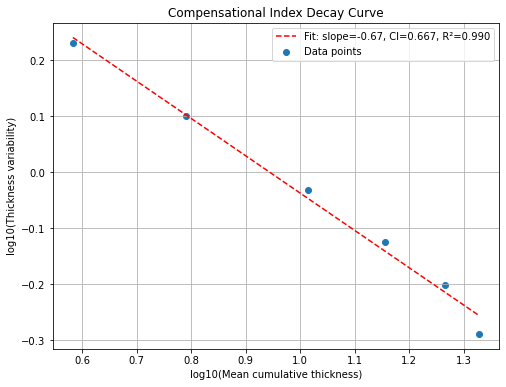

Computed CI: 0.667


In [3]:
# SCRIPT 2: Compensational Index Calculation (with explicit chronology)
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Load manually ordered data
metrics_df = pd.read_csv("lobe_metrics.csv")
metrics_df = metrics_df.sort_values(by="Chrono_Order")

thickness_profiles = np.load("thickness_profiles.npy", allow_pickle=True).item()

# Common interpolation grid
x_common = np.linspace(22000, 30400, 2000)
thickness_grid = []

# Stack thickness profiles in explicit chronological order
for _, row in metrics_df.iterrows():
    label_id = row["Auto_Label_ID"]
    profile = thickness_profiles[label_id]
    interp_t = np.interp(x_common, profile["x_coords"], profile["thickness_vals"], left=0, right=0)
    thickness_grid.append(interp_t)

# Compute cumulative stacking
cumulative = np.cumsum(thickness_grid, axis=0)

# Compute CI
H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H, log_sss = np.log10(H), np.log10(sss)
    slope, intercept, r_value, _, _ = linregress(log_H, log_sss)
    CI = -slope

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, label="Data points")
    plt.plot(log_H, intercept + slope * log_H, "r--",
             label=f"Fit: slope={slope:.2f}, CI={CI:.3f}, R²={r_value**2:.3f}")
    plt.xlabel('log10(Mean cumulative thickness)')
    plt.ylabel('log10(Thickness variability)')
    plt.title('Compensational Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Computed CI: {CI:.3f}")
else:
    print("Insufficient data points for CI calculation.")


In [11]:
# SCRIPT 1: Lobe Identification and Metrics Extraction
import cv2
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

# Parameters
real_width_m = 26700 - 21400
real_height_m = 60
min_area_m2 = 5000

# Load and preprocess image
img = cv2.imread("filled_lobes_Frd10b.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# Label regions
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# Dimensions and scaling
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# Extract metrics and thickness profiles
metrics, thickness_profiles = [], {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 21400 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Auto_Label_ID": region.label,
        "Area_m2": area_m2,
        "Width_m": width_m,
        "Height_m": height_m,
        "Centroid_X_m": cx_m,
        "Centroid_Z_m": cz_m
    })

    label_mask = (labeled == region.label)
    x_coords, thickness_vals = [], []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 21400 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    thickness_profiles[region.label] = {
        "x_coords": x_coords,
        "thickness_vals": thickness_vals
    }

# Export data
pd.DataFrame(metrics).to_csv("lobe_metrics10.csv", index=False)
np.save("thickness_profiles10.npy", thickness_profiles)


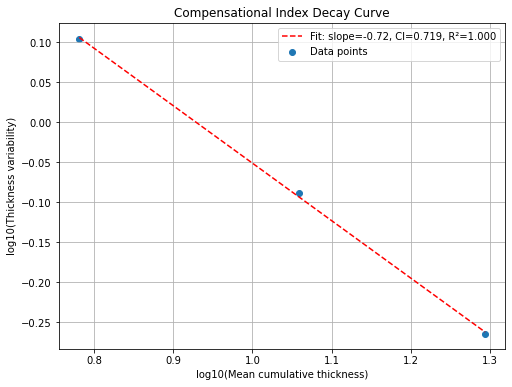

Computed CI: 0.719


In [19]:
# SCRIPT 2: Compensational Index Calculation (with explicit chronology)
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Load manually ordered data
metrics_df = pd.read_csv("lobe_metrics10.csv")
metrics_df = metrics_df.sort_values(by="Chrono_Order")

thickness_profiles = np.load("thickness_profiles10.npy", allow_pickle=True).item()

# Common interpolation grid
x_common = np.linspace(21400, 26700, 2000)
thickness_grid = []

# Stack thickness profiles in explicit chronological order
for _, row in metrics_df.iterrows():
    label_id = row["Auto_Label_ID"]
    profile = thickness_profiles[label_id]
    interp_t = np.interp(x_common, profile["x_coords"], profile["thickness_vals"], left=0, right=0)
    thickness_grid.append(interp_t)

# Compute cumulative stacking
cumulative = np.cumsum(thickness_grid, axis=0)

# Compute CI
H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H, log_sss = np.log10(H), np.log10(sss)
    slope, intercept, r_value, _, _ = linregress(log_H, log_sss)
    CI = -slope

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, label="Data points")
    plt.plot(log_H, intercept + slope * log_H, "r--",
             label=f"Fit: slope={slope:.2f}, CI={CI:.3f}, R²={r_value**2:.3f}")
    plt.xlabel('log10(Mean cumulative thickness)')
    plt.ylabel('log10(Thickness variability)')
    plt.title('Compensational Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Computed CI: {CI:.3f}")
else:
    print("Insufficient data points for CI calculation.")


In [17]:
# SCRIPT 1: Lobe Identification and Metrics Extraction
import cv2
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops

# Parameters
real_width_m = 29200 - 22400
real_height_m = 60
min_area_m2 = 5000

# Load and preprocess image
img = cv2.imread("filled_lobes_Frd05b.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# Label regions
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# Dimensions and scaling
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# Extract metrics and thickness profiles
metrics, thickness_profiles = [], {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22400 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Auto_Label_ID": region.label,
        "Area_m2": area_m2,
        "Width_m": width_m,
        "Height_m": height_m,
        "Centroid_X_m": cx_m,
        "Centroid_Z_m": cz_m
    })

    label_mask = (labeled == region.label)
    x_coords, thickness_vals = [], []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22400 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    thickness_profiles[region.label] = {
        "x_coords": x_coords,
        "thickness_vals": thickness_vals
    }

# Export data
pd.DataFrame(metrics).to_csv("lobe_metrics5.csv", index=False)
np.save("thickness_profiles5.npy", thickness_profiles)


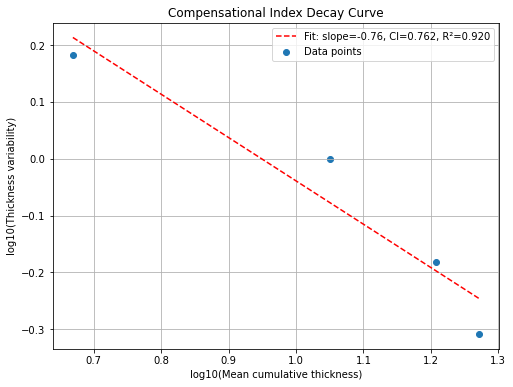

Computed CI: 0.762


In [18]:
# SCRIPT 2: Compensational Index Calculation (with explicit chronology)
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Load manually ordered data
metrics_df = pd.read_csv("lobe_metrics5.csv")
metrics_df = metrics_df.sort_values(by="Chrono_Order")

thickness_profiles = np.load("thickness_profiles5.npy", allow_pickle=True).item()

# Common interpolation grid
x_common = np.linspace(22400, 29200, 2000)
thickness_grid = []

# Stack thickness profiles in explicit chronological order
for _, row in metrics_df.iterrows():
    label_id = row["Auto_Label_ID"]
    profile = thickness_profiles[label_id]
    interp_t = np.interp(x_common, profile["x_coords"], profile["thickness_vals"], left=0, right=0)
    thickness_grid.append(interp_t)

# Compute cumulative stacking
cumulative = np.cumsum(thickness_grid, axis=0)

# Compute CI
H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H, log_sss = np.log10(H), np.log10(sss)
    slope, intercept, r_value, _, _ = linregress(log_H, log_sss)
    CI = -slope

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(log_H, log_sss, label="Data points")
    plt.plot(log_H, intercept + slope * log_H, "r--",
             label=f"Fit: slope={slope:.2f}, CI={CI:.3f}, R²={r_value**2:.3f}")
    plt.xlabel('log10(Mean cumulative thickness)')
    plt.ylabel('log10(Thickness variability)')
    plt.title('Compensational Index Decay Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Computed CI: {CI:.3f}")
else:
    print("Insufficient data points for CI calculation.")
